# NB3 - Recovering the haemodynamic response (block average & GLM)

*fNIRS block course - accompanies slides 16-21*

This is the heart of task-based fNIRS analysis. We now use the dataset's
**ground-truth** files: a *synthetic* haemodynamic response (a gamma HRF, peak
~6 s) was added to a **random half of the long channels** of the resting
recording, in short blocks. Because we know exactly **which channels** carry a
response and **what it should look like**, we can check whether our analysis
actually recovers it.

**We will**
1. Load `resting_hrf_100.snirf` (stim markers + ground-truth channel flags)
2. Preprocess to HbO/HbR (the NB2 pipeline, compactly)
3. Identify the **ground-truth** HRF-bearing channels
4. **Block-average** the response and compare HRF vs silent channels
5. Fit a **GLM** and map the response across the montage
6. Compare nuisance strategies: auxiliary sensors, short channels, and a strict
   long-channel-only band-pass
7. Repeat across **several subjects**


In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import xarray as xr
import h5py
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt

import cedalion
import cedalion.io
import cedalion.nirs
import cedalion.nirs.cw as cw
import cedalion.dataclasses as cdc
import cedalion.sigproc.motion as motion
import cedalion.sigproc.frequency as frequency
import cedalion.sigproc.epochs as epochs
import cedalion.models.glm as glm
import cedalion.models.glm.design_matrix as dm
import cedalion.vis.anatomy as vis_anatomy
from cedalion import units

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["figure.dpi"] = 110

def find_data(subdir="resting_state_1"):
    """Locate the dataset folder. Download it from the NITRC links in the
    README and extract into ./data/ so you have data/resting_state_1/."""
    here = os.getcwd()
    for c in [os.path.join(here, "data", subdir),
              os.path.join(here, "..", "data", subdir),
              os.path.join(here, subdir),
              os.path.join(here, "..", subdir)]:
        if os.path.isdir(c):
            return os.path.abspath(c)
    raise FileNotFoundError(
        f"'{subdir}' not found. See the README: download the data from NITRC "
        f"and extract it into the data/ folder (data/{subdir}/).")

DATA = find_data("resting_state_1")


### Helper functions

`load_montage` and `hrf_channels` read the SNIRF probe and measurement list
directly. `preprocess` runs the NB2 pipeline and returns clean HbO/HbR plus the
long/short split. The helper functions at the end build optional auxiliary
sensor regressors and summarize GLM recovery against the known ground truth.


In [2]:
def load_montage(path):
    with h5py.File(path, "r") as h:
        pr = h["nirs/probe"]
        src_labels = [s.decode() for s in np.array(pr["sourceLabels"])]
        det_labels = [d.decode() for d in np.array(pr["detectorLabels"])]
        src_pos = np.array(pr["sourcePos2D"])
        det_pos = np.array(pr["detectorPos2D"])
    labels = np.array(src_labels + det_labels)
    types = ([cdc.PointType.SOURCE] * len(src_labels)
             + [cdc.PointType.DETECTOR] * len(det_labels))
    pos = np.vstack([
        np.column_stack([src_pos, np.zeros(len(src_pos))]),
        np.column_stack([det_pos, np.zeros(len(det_pos))]),
    ])
    return xr.DataArray(
        pos, dims=["label", "pos"],
        coords={"label": ("label", labels), "type": ("label", types)},
        attrs={"units": "mm"},
    ).pint.quantify()


def hrf_channels(path):
    """Ground-truth channels: measurementList dataTypeLabel == 1."""
    chs = set(); i = 1
    with h5py.File(path, "r") as h:
        while ("nirs/data1/measurementList%d" % i) in h:
            ml = h["nirs/data1/measurementList%d" % i]
            s = int(np.array(ml["sourceIndex"]))
            d = int(np.array(ml["detectorIndex"]))
            if float(np.array(ml["dataTypeLabel"])) == 1.0:
                chs.add("S%dD%d" % (s, d))
            i += 1
    return sorted(chs)


def preprocess(path, band=(0.01, 0.5)):
    """NB2 pipeline: intensity -> OD -> TDDR -> band-pass -> HbO/HbR."""
    rec = cedalion.io.read_snirf(path)[0]
    amp = rec["amp"]; amp.time.attrs["units"] = "s"
    # a few subjects have isolated non-positive (dark/saturated) samples;
    # interpolate them out so the log in int2od is well-defined
    amp = amp.where(amp > 0)
    amp = amp.interpolate_na(dim="time", method="linear")
    amp = amp.fillna(amp.mean("time"))   # any remaining edge gaps -> channel mean
    geo3d = load_montage(path)
    od = cw.int2od(amp)
    od = motion.tddr(od)
    od = frequency.freq_filter(od, band[0] * units.Hz, band[1] * units.Hz,
                               butter_order=4)
    dpf = xr.DataArray([6.0, 6.0], dims=["wavelength"],
                       coords={"wavelength": [690.0, 830.0]})
    conc = cw.od2conc(od, geo3d, dpf, spectrum="prahl").pint.to("micromolar")
    ts_long, ts_short = cedalion.nirs.split_long_short_channels(
        conc, geo3d, distance_threshold=1.5 * units.cm)
    return rec, geo3d, conc, ts_long, ts_short


def aux_sensor_regressors(rec, ts, names=("PPG", "BP", "RESP"), band=(0.01, 0.5)):
    """Create common GLM nuisance regressors from auxiliary sensors."""
    t = np.asarray(ts.time.values, dtype=float)
    fs = float(1.0 / np.median(np.diff(t)))
    sos = butter(4, band, btype="bandpass", fs=fs, output="sos")
    cols, labels = [], []
    for name in names:
        if name not in rec.aux_ts:
            continue
        aux = rec.aux_ts[name]
        if not np.allclose(aux.time.values, t):
            aux = aux.interp(time=ts.time)
        x = np.asarray(aux.values, dtype=float)
        fill = np.nanmean(x)
        if not np.isfinite(fill):
            fill = 0.0
        x = np.nan_to_num(x, nan=fill)
        x = sosfiltfilt(sos, x)
        x = (x - x.mean()) / (x.std() or 1.0)
        cols.append(x)
        labels.append(f"Aux {name}")
    if not cols:
        return dm.DesignMatrix()
    data = np.stack(cols, axis=1)[:, :, None] * np.ones((1, 1, ts.sizes["chromo"]))
    regs = xr.DataArray(
        data, dims=["time", "regressor", "chromo"],
        coords={"time": ts.time, "regressor": labels, "chromo": ts.chromo})
    return dm.DesignMatrix(common=regs)


def fit_hrf_beta(ts, design):
    results = glm.fit(ts, design, noise_model="ols", max_jobs=1)
    betas = results.sm.params
    hrf_reg = [r for r in betas.regressor.values if "HRF" in str(r)][0]
    return results, betas.sel(regressor=hrf_reg, chromo="HbO")


def beta_summary(label, beta_hbo, hrf_channels, silent_channels):
    bh = np.array([float(beta_hbo.sel(channel=c)) for c in hrf_channels])
    bs = np.array([float(beta_hbo.sel(channel=c)) for c in silent_channels])
    pooled = np.sqrt(0.5 * (bh.var() + bs.var())) or np.nan
    return {
        "label": label,
        "hrf_mean": float(bh.mean()),
        "silent_mean": float(bs.mean()),
        "silent_sd": float(bs.std()),
        "separation": float((bh.mean() - bs.mean()) / pooled),
    }


## The task design and ground truth

The stimulus onsets are stored in the SNIRF file. The synthetic HRF was added to
half the long channels; their identity is flagged by `dataTypeLabel == 1`.

In [3]:
SUBJECT = "Subj33"
snirf_file = os.path.join(DATA, SUBJECT, "resting_hrf_100.snirf")

rec, geo3d, conc, ts_long, ts_short = preprocess(snirf_file)
hrf_ch = hrf_channels(snirf_file)

long_all = list(ts_long.channel.values.astype(str))
long_hrf = [c for c in long_all if c in hrf_ch]
long_silent = [c for c in long_all if c not in hrf_ch]

print(f"stim events     : {len(rec.stim)}")
print(f"long channels   : {len(long_all)}  ({len(long_hrf)} with HRF, "
      f"{len(long_silent)} silent)")
print(f"short channels  : {ts_short.sizes['channel']}")
print("\nstim onsets (s):", list(np.round(rec.stim.onset.values, 1)))

stim events     : 15

long channels   : 26  (13 with HRF, 13 silent)

short channels  : 8


stim onsets (s):

[np.float64(2.3), np.float64(23.0), np.float64(41.0), np.float64(63.0), np.float64(80.3), np.float64(101.3), np.float64(120.9), np.float64(140.5), np.float64(162.2), np.float64(181.1), np.float64(203.4), np.float64(221.8), np.float64(242.6), np.float64(260.1), np.float64(282.1)]

**Where is the response?** The montage below highlights the
ground-truth HRF channels (orange). These are the channels where block averaging
and the GLM *should* find a response - everything else should stay flat.

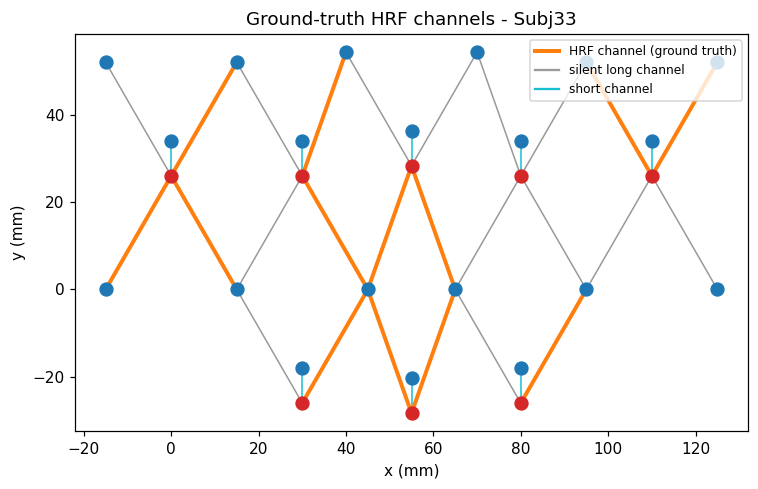

In [4]:
g = geo3d.pint.dequantify()
pos2d = {lab: g.sel(label=lab).values[:2] for lab in g.label.values}
is_src = {lab: (t == cdc.PointType.SOURCE)
          for lab, t in zip(g.label.values, g["type"].values)}

fig, ax = plt.subplots(figsize=(7, 7))
for ch, s, d in zip(conc.channel.values, conc.source.values, conc.detector.values):
    ch = str(ch)
    xs, ys = pos2d[s], pos2d[d]
    if ch in hrf_ch:
        col, lw = "tab:orange", 2.6
    elif ch in long_silent:
        col, lw = "0.6", 1.0
    else:
        col, lw = "tab:cyan", 1.0   # short channels
    ax.plot([xs[0], ys[0]], [xs[1], ys[1]], color=col, lw=lw, zorder=1)
for lab, xy in pos2d.items():
    c = "tab:red" if is_src[lab] else "tab:blue"
    ax.scatter(*xy, c=c, s=70, zorder=3)
handles = [plt.Line2D([], [], c="tab:orange", lw=2.6, label="HRF channel (ground truth)"),
           plt.Line2D([], [], c="0.6", label="silent long channel"),
           plt.Line2D([], [], c="tab:cyan", label="short channel")]
ax.legend(handles=handles, loc="upper right", fontsize=8)
ax.set_title(f"Ground-truth HRF channels - {SUBJECT}")
ax.set_xlabel("x (mm)"); ax.set_ylabel("y (mm)"); ax.set_aspect("equal")
plt.tight_layout(); plt.show()

## Block averaging

The simplest analysis: cut the signal into **epochs** around each stimulus onset
and **average** them. Random noise averages out; the time-locked response
remains. `cedalion.sigproc.epochs.to_epochs` builds the epochs; we baseline-
correct on the pre-stimulus interval and average over the 15 blocks.

In [5]:
ep = epochs.to_epochs(ts_long, rec.stim, ["1"],
                      before=5 * units.s, after=20 * units.s)
baseline = ep.sel(reltime=slice(-5, 0)).mean("reltime")
ep_bc = ep - baseline
block_avg = ep_bc.mean("epoch")           # (chromo, channel, reltime)
rt = block_avg.reltime.values
print("epochs:", ep.sizes["epoch"], "| reltime", rt[0], "..", rt[-1], "s")

epochs:

13

| reltime

-5.0

..

20.0

s

### Recovered response: HRF vs silent channels

Averaging HbO/HbR across the HRF channels and, separately, across the silent
channels makes the recovery obvious: a clear **positive HbO / negative HbR**
deflection on the HRF channels, and essentially **flat** silent channels.

We overlay the **known gamma HRF shape** (peak ~6 s) the data were built from -
the recovered timing and shape match. (The recovered amplitude is somewhat
smaller than the injected +0.66 uM because band-pass filtering attenuates the
block edges.)

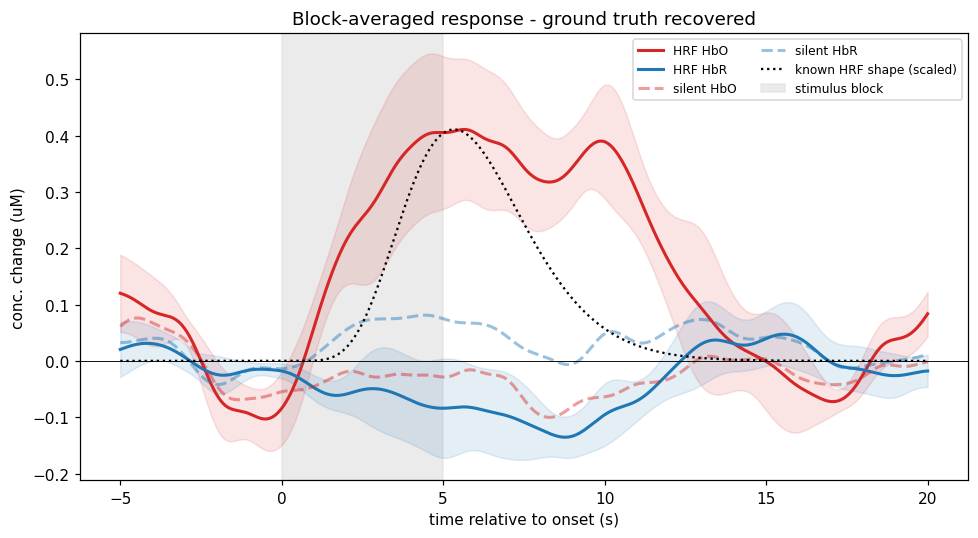

HbO peak (4-10 s):  HRF channels = 0.411 uM   silent = -0.016 uM

In [6]:
def gamma_hrf(t, peak=6.0, undershoot=16.0, ratio=0.0):
    from scipy.stats import gamma as _g
    a1 = (peak ** 2) / 4.0; b1 = peak / a1
    h = _g.pdf(np.clip(t, 0, None), a1, scale=b1)
    return h / h.max()

grp_hrf = block_avg.sel(channel=long_hrf)
grp_sil = block_avg.sel(channel=long_silent)

fig, ax = plt.subplots(figsize=(9, 5))
for grp, cc, name, ls in [(grp_hrf, "HbO", "HRF HbO", "-"),
                          (grp_hrf, "HbR", "HRF HbR", "-"),
                          (grp_sil, "HbO", "silent HbO", "--"),
                          (grp_sil, "HbR", "silent HbR", "--")]:
    m = grp.sel(chromo=cc).mean("channel").pint.magnitude
    sd = grp.sel(chromo=cc).std("channel").pint.magnitude
    color = "tab:red" if cc == "HbO" else "tab:blue"
    alpha = 1.0 if name.startswith("HRF") else 0.45
    ax.plot(rt, m, ls, color=color, alpha=alpha, lw=2, label=name)
    if name.startswith("HRF"):
        ax.fill_between(rt, m - sd, m + sd, color=color, alpha=0.12)

gt = gamma_hrf(rt) * float(grp_hrf.sel(chromo="HbO").mean("channel").pint.magnitude.max())
ax.plot(rt, gt, ":", color="k", lw=1.5, label="known HRF shape (scaled)")
ax.axvspan(0, 5, color="0.85", alpha=0.5, zorder=0, label="stimulus block")
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("time relative to onset (s)")
ax.set_ylabel("conc. change (uM)")
ax.set_title("Block-averaged response - ground truth recovered")
ax.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()

peak_hrf = float(grp_hrf.sel(chromo="HbO").mean("channel")
                 .sel(reltime=slice(4, 10)).max().pint.magnitude)
peak_sil = float(grp_sil.sel(chromo="HbO").mean("channel")
                 .sel(reltime=slice(4, 10)).max().pint.magnitude)
print(f"HbO peak (4-10 s):  HRF channels = {peak_hrf:.3f} uM   "
      f"silent = {peak_sil:.3f} uM")

### Single HRF channel

The group average is clean, but a single channel already shows the response
across its 15 individual epochs (thin lines) with the average on top.

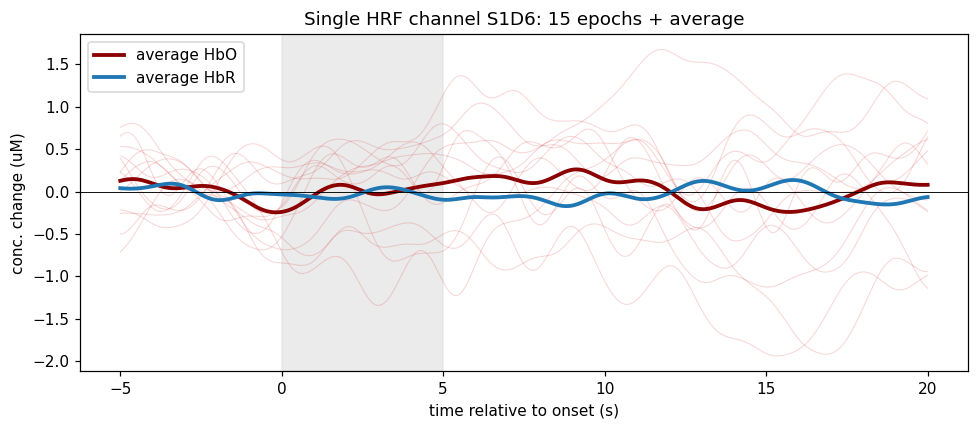

In [7]:
ch = long_hrf[0]
fig, ax = plt.subplots()
for e in range(ep_bc.sizes["epoch"]):
    ax.plot(rt, ep_bc.isel(epoch=e).sel(channel=ch, chromo="HbO").pint.magnitude,
            color="tab:red", alpha=0.18, lw=0.7)
ax.plot(rt, block_avg.sel(channel=ch, chromo="HbO").pint.magnitude,
        color="darkred", lw=2.5, label="average HbO")
ax.plot(rt, block_avg.sel(channel=ch, chromo="HbR").pint.magnitude,
        color="tab:blue", lw=2.5, label="average HbR")
ax.axvspan(0, 5, color="0.85", alpha=0.5, zorder=0)
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("time relative to onset (s)"); ax.set_ylabel("conc. change (uM)")
ax.set_title(f"Single HRF channel {ch}: 15 epochs + average")
ax.legend(); plt.tight_layout(); plt.show()

## The GLM

Block averaging is intuitive but discards information and cannot easily separate
overlapping responses or systemic drift. The **General Linear Model** fits the
whole time series as a weighted sum of **regressors**:

- an **HRF regressor** (a gamma basis convolved with the stimulus),
- **drift** regressors (slow trends),
- optional nuisance regressors, such as **short channels** or auxiliary sensors.

The fitted weight (**beta**) of the HRF regressor is the response amplitude.
`cedalion.models.glm` builds the design matrix and fits it. We start with the
broad-band pipeline plus short-channel regression, then compare it with other
reasonable choices below.


regressors:

['HRF 1', 'Drift 0', 'Drift 1', 'short']

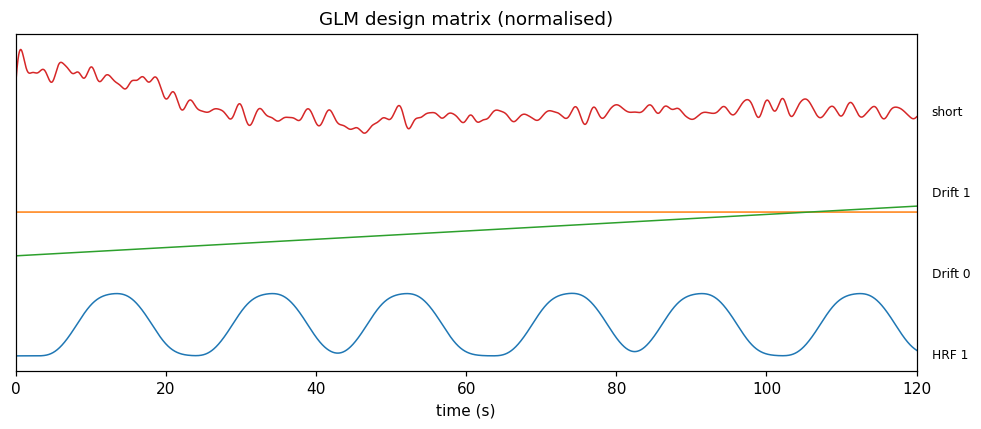

In [8]:
basis = glm.Gamma(tau=0 * units.s, sigma=3 * units.s, T=10 * units.s)
design = (dm.hrf_regressors(ts_long, rec.stim, basis)
          & dm.drift_regressors(ts_long, drift_order=1)
          & dm.average_short_channel_regressor(ts_short))
print("regressors:", [str(r) for r in design.common.regressor.values])

# visualise the design matrix (HbO) over the first 120 s
X = design.common.sel(chromo="HbO")
t = X.time.values
fig, ax = plt.subplots(figsize=(9, 4))
for i, r in enumerate(X.regressor.values):
    col = X.sel(regressor=r).values
    col = col / (np.nanmax(np.abs(col)) or 1)
    ax.plot(t, col + i * 1.3, lw=1)
    ax.text(122, i * 1.3, str(r), va="center", fontsize=8)
ax.set_xlim(0, 120); ax.set_yticks([])
ax.set_xlabel("time (s)"); ax.set_title("GLM design matrix (normalised)")
plt.tight_layout(); plt.show()

HRF-regressor HbO beta:  HRF channels = 0.0005 +/- 0.0002

                         silent       = -0.0002 +/- 0.0002

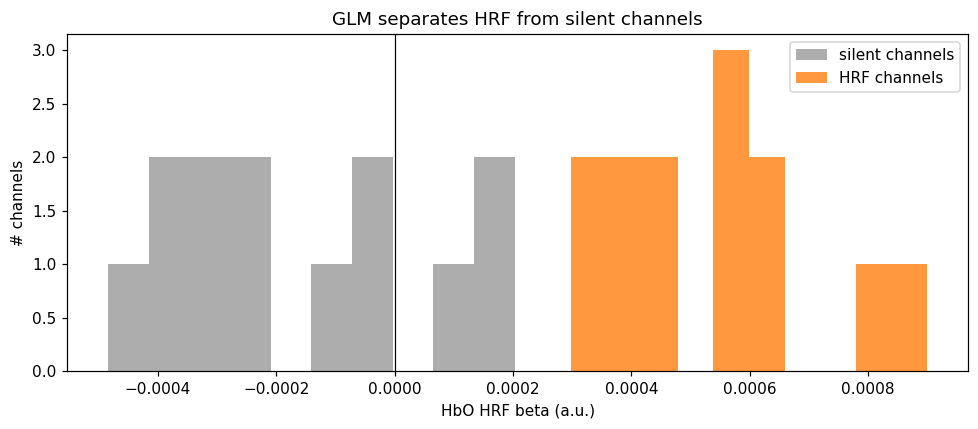

In [9]:
results, beta_hbo = fit_hrf_beta(ts_long, design)

bh = np.array([float(beta_hbo.sel(channel=c)) for c in long_hrf])
bs = np.array([float(beta_hbo.sel(channel=c)) for c in long_silent])
print(f"HRF-regressor HbO beta:  HRF channels = {bh.mean():.4f} +/- {bh.std():.4f}")
print(f"                         silent       = {bs.mean():.4f} +/- {bs.std():.4f}")

fig, ax = plt.subplots()
ax.hist(bs, bins=10, color="0.6", alpha=0.8, label="silent channels")
ax.hist(bh, bins=10, color="tab:orange", alpha=0.8, label="HRF channels")
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("HbO HRF beta (a.u.)"); ax.set_ylabel("# channels")
ax.set_title("GLM separates HRF from silent channels")
ax.legend(); plt.tight_layout(); plt.show()


### Spatial map of the response

Painting each channel's HbO beta onto the montage (at the source-detector
midpoint) shows the **spatial pattern**: the HRF channels light up red; the
silent ones stay near zero - the GLM has recovered the (synthetic) activation
map.

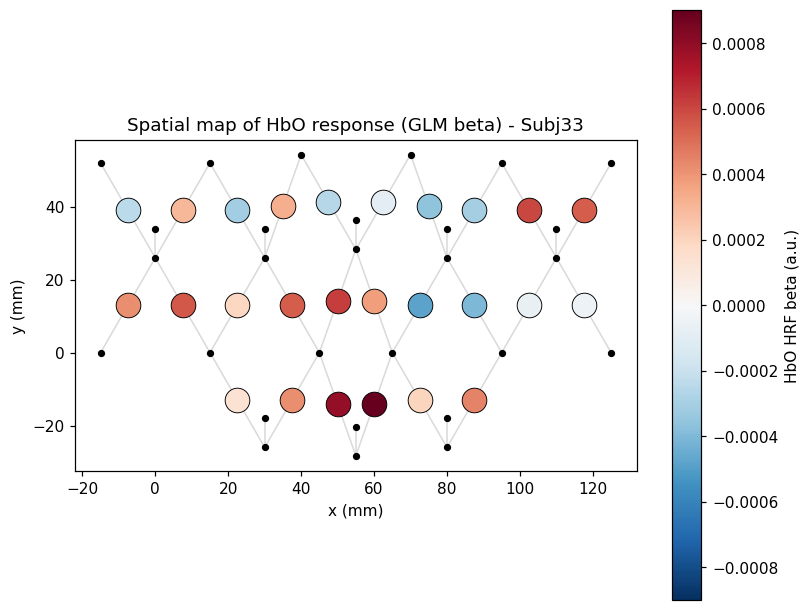

In [10]:
vmax = float(np.abs(beta_hbo.values).max())
cmap = plt.cm.RdBu_r
norm = plt.Normalize(-vmax, vmax)

fig, ax = plt.subplots(figsize=(7.5, 7))
# faint montage backbone
for ch, s, d in zip(conc.channel.values, conc.source.values, conc.detector.values):
    xs, ys = pos2d[s], pos2d[d]
    ax.plot([xs[0], ys[0]], [xs[1], ys[1]], color="0.85", lw=1, zorder=0)
# colour each long channel by its beta
for c in long_all:
    s = str(ts_long.source.sel(channel=c).values)
    d = str(ts_long.detector.sel(channel=c).values)
    mid = (pos2d[s] + pos2d[d]) / 2.0
    val = float(beta_hbo.sel(channel=c))
    ax.scatter(*mid, c=[cmap(norm(val))], s=260, edgecolor="k",
               linewidth=0.6, zorder=2)
for lab, xy in pos2d.items():
    ax.scatter(*xy, c="k", s=14, zorder=3)
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax,
             label="HbO HRF beta (a.u.)", shrink=0.8)
ax.set_title(f"Spatial map of HbO response (GLM beta) - {SUBJECT}")
ax.set_xlabel("x (mm)"); ax.set_ylabel("y (mm)"); ax.set_aspect("equal")
plt.tight_layout(); plt.show()

## Compare nuisance strategies

Short-channel regression is useful when superficial physiology remains in the
same frequency range as the task response. But if we use a strict band-pass
filter first, much of that variability may already be removed from both long and
short channels. That can make the short-channel regressor look unimportant even
though it would matter in a broader-band or more realistic recording.

Here we compare four choices:

- **broad + long only**: 0.01-0.5 Hz, no nuisance regressor.
- **broad + short channels**: 0.01-0.5 Hz plus average short-channel regressor.
- **broad + auxiliary sensors**: 0.01-0.5 Hz plus PPG, blood-pressure and
  respiration regressors.
- **strict + long only**: 0.01-0.09 Hz, a stricter low-pass choice often used to
  suppress Mayer-wave and faster physiology.

The point is not that one option always wins. It is that filtering and nuisance
regression answer related questions, and a strict filter can hide the variance
that short-channel or auxiliary regressors would otherwise explain.


model                     HRF mean  silent SD  separation

broad + long only           0.0005     0.0002        3.52

broad + short channels      0.0005     0.0002        3.49

broad + aux sensors         0.0005     0.0002        3.48

strict + long only          0.0006     0.0002        3.85

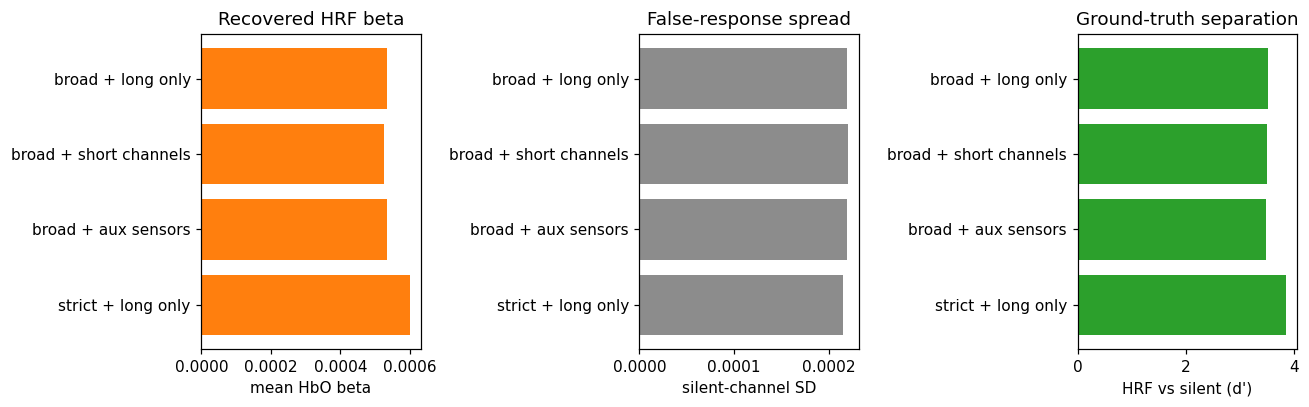


In these synthetic files the nuisance regressors change the result only modestly; the strict filter performs well because it removes much physiological variance up front.

In [11]:
design_long_only = (dm.hrf_regressors(ts_long, rec.stim, basis)
                    & dm.drift_regressors(ts_long, drift_order=1))
design_short = design

design_aux = (dm.hrf_regressors(ts_long, rec.stim, basis)
              & dm.drift_regressors(ts_long, drift_order=1)
              & aux_sensor_regressors(rec, ts_long, band=(0.01, 0.5)))

# Strict low-pass example: removes Mayer-wave-scale physiology before the GLM.
_, _, _, ts_long_strict, _ = preprocess(snirf_file, band=(0.01, 0.09))
design_strict = (dm.hrf_regressors(ts_long_strict, rec.stim, basis)
                 & dm.drift_regressors(ts_long_strict, drift_order=1))

variants = []
for label, ts, design_variant in [
    ("broad + long only", ts_long, design_long_only),
    ("broad + short channels", ts_long, design_short),
    ("broad + aux sensors", ts_long, design_aux),
    ("strict + long only", ts_long_strict, design_strict),
]:
    _, beta = fit_hrf_beta(ts, design_variant)
    variants.append(beta_summary(label, beta, long_hrf, long_silent))

print(f"{'model':24s} {'HRF mean':>9s} {'silent SD':>10s} {'separation':>11s}")
for row in variants:
    print(f"{row['label']:24s} {row['hrf_mean']:9.4f} "
          f"{row['silent_sd']:10.4f} {row['separation']:11.2f}")

labels = [v["label"] for v in variants]
hrf_means = [v["hrf_mean"] for v in variants]
silent_sd = [v["silent_sd"] for v in variants]
sep = [v["separation"] for v in variants]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
axes[0].barh(labels, hrf_means, color="tab:orange")
axes[0].set_title("Recovered HRF beta")
axes[0].set_xlabel("mean HbO beta")
axes[1].barh(labels, silent_sd, color="0.55")
axes[1].set_title("False-response spread")
axes[1].set_xlabel("silent-channel SD")
axes[2].barh(labels, sep, color="tab:green")
axes[2].set_title("Ground-truth separation")
axes[2].set_xlabel("HRF vs silent (d')")
for ax in axes:
    ax.invert_yaxis()
plt.tight_layout(); plt.show()

print("\nIn these synthetic files the nuisance regressors change the result only modestly; "
      "the strict filter performs well because it removes much physiological variance up front.")


## Across subjects

The synthetic HRF was added to every subject. Running the same block-average
pipeline over a few subjects shows the recovery is **consistent**: HRF channels
always show a clear HbO peak, silent channels stay flat.

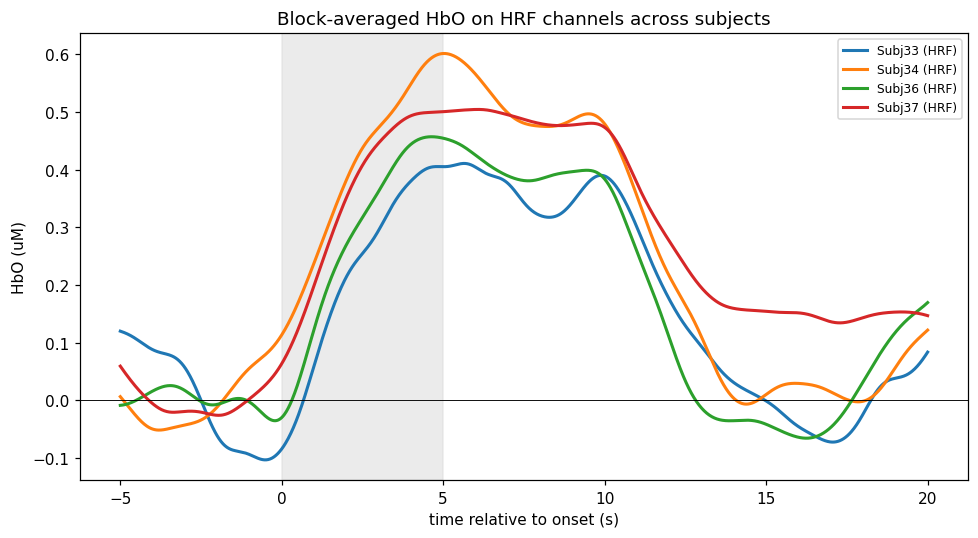

subject     HRF peak uM  silent peak uM

Subj33            0.411          -0.016

Subj34            0.601           0.088

Subj36            0.457          -0.049

Subj37            0.504           0.080

In [12]:
subjects = ["Subj33", "Subj34", "Subj36", "Subj37"]
rows = []
fig, ax = plt.subplots(figsize=(9, 5))
for subj in subjects:
    p = os.path.join(DATA, subj, "resting_hrf_100.snirf")
    if not os.path.exists(p):
        continue
    rec_s, geo_s, conc_s, long_s, short_s = preprocess(p)
    hrf_s = hrf_channels(p)
    la = list(long_s.channel.values.astype(str))
    lh = [c for c in la if c in hrf_s]; ls_ = [c for c in la if c not in hrf_s]
    ep_s = epochs.to_epochs(long_s, rec_s.stim, ["1"],
                            before=5 * units.s, after=20 * units.s)
    bc = ep_s - ep_s.sel(reltime=slice(-5, 0)).mean("reltime")
    ba = bc.mean("epoch")
    rts = ba.reltime.values
    mh = ba.sel(channel=lh, chromo="HbO").mean("channel").pint.magnitude
    ax.plot(rts, mh, lw=2, label=f"{subj} (HRF)")
    ph = float(np.nanmax(mh[(rts >= 4) & (rts <= 10)]))
    psil = float(np.nanmax(
        ba.sel(channel=ls_, chromo="HbO").mean("channel").pint.magnitude[(rts >= 4) & (rts <= 10)]))
    rows.append((subj, ph, psil))
ax.axvspan(0, 5, color="0.85", alpha=0.5, zorder=0)
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("time relative to onset (s)"); ax.set_ylabel("HbO (uM)")
ax.set_title("Block-averaged HbO on HRF channels across subjects")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

print(f"{'subject':10s} {'HRF peak uM':>12s} {'silent peak uM':>15s}")
for subj, ph, psil in rows:
    print(f"{subj:10s} {ph:12.3f} {psil:15.3f}")

## Takeaways

- With a **known ground truth**, we can verify the pipeline: both **block
  averaging** and the **GLM** recover a clear HbO/HbR response on exactly the
  channels where the synthetic HRF was injected, and leave silent channels flat.
- **Block averaging** is intuitive and assumption-light; the **GLM** is more
  flexible (handles drift, overlapping events, nuisance regressors) and yields a
  single beta per channel that maps naturally onto the scalp.
- Filtering and nuisance regression interact: a strict band-pass can make
  short-channel or auxiliary regressors look less useful because it has already
  removed much of the systemic variance.
- The recovery is **consistent across subjects**.

This is the standard task-fNIRS workflow - applied here to synthetic data so the
answer is known, but identical in form to a real experiment.
